# Perceptrons and neural networks

_Notebook made by Zaid De Anda 🐱‍💻_

Nature has always inspired us to build solutions, like how we made planes from watching birds fly. Similarly, we observed how our brain works to make intelligent machines.

This notebook is based on a book called "Hands On Machine Learning with scikit-learn and pytorch". Really recommend it

Let's start with a small definition. What's machine learning?

> A computer program is said to learn from experience E with respect to some task T and some performance measure P, if its performance on T, as measured by P, improves with experience E
> -Tom Mitchell, 1997

So according to this, a ML model it's one that learns with time on a task.

## Artificial neural networks.

They were introduced in 1943 by Warren McCulloch and Walter Pitts in "A logical calculus of Ideas Immanent in nervous activity". they presented a simplified model of how biological neurons might work together to perform complex computations.

At that time, they believed with this technology, they would be talking with smart machines in small time! Sadly, by 1960, they realized this wouldnt happen so research in ANN's stopped for some time. It was until 1990's that other ML techniques began to shine and this brought interest back to ANN's. and advances like:

* Rise in computing power (Moore's law, the number of components in integrated circuits has doubled about every 2 years over the last 50 years)
* huge quantity of data available
* Training algorithms have been improved (we have backpropagation!)
* Thanks to gaming, we have GPU's!

## Biological neurons

Before anything, let's discuss about biological neurons.

HUGE DISCLAIMER, I'm not a neuroscientist, this is just an approximation of the truth valid for teaching the concepts. Some things might be wrong if you look hard enough.



![img](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQJ0sEOg-GYs3AQl4TN0JTbPTgnMPsD-dnulYEYR9BZl3LlS0_FqQYIcg61&s=10)


Drawing of neurons by Otto Friedrich Karl Deiters at 1886

Neurons are composed by a cell body, some extensions called dendrites, and one very long extension called axon. Neurons produce short electrical impulses called _Action potentials_ (or just signals) which travel along the axons and make the synapses release chemical signals called _neurotransmitters_. when a neuron receives enough neurotransmitters within a few miliseconds, it fires it's own electrical impulses.

they seem very simple, but they are organized in networks of billions interconnected neurons! Research has showed that neurons are often organized in consecutive layers, especially in the cerebral cortex 

![img](https://upload.wikimedia.org/wikipedia/commons/5/5b/Cajal_cortex_drawings.png)

drawing of a cortical lamination

## Perceptrons

So, we can abstract the neuron form to a mathematical concept, so much fun!

Neurons basically:
* receive some inputs through the axon
* if those inputs rise above a threshold, they fire a signal

so we can model them like this! 

![img](https://towardsdatascience.com/wp-content/uploads/2021/11/1YA-0MyBLsn8BiThBGjycIA.png)

diagram of an artificial neuron

we can see it has some inputs x1, x2, ..., xn; associated with some weights w1, w2, ..., wn; and an activation function, which is kinda the same as human neurons!

In mathematical terms, the perceptron computed a _weighted sum_ of its inputs

$$
z = w_1x_1 + w_2x_2 + ... + w_nx_n = X^Tw
$$

then applies a step function to that sum and output the result.

lil eye 👀: if you have taken a linear algebra course, you'll notice this is a dot product of the input vector @ weight matrix

you can see this as a simple diagnosis tool. imagine instead of numerical outputs, you have age, weight, % of some chemical in the blood; of a patient. a perceptron would take each input, multiply by its weight (you can see it as the "importance" of each input, and see if it arises some treshold)

QUIZ!

What's the shape of the output of the perceptron?

hint: is it a square? a curve? a triangle?

let's write a perceptron!

In [24]:
import numpy as np

def step(z):
    return (z >= 0).astype(int)


# First, let's compute one example by hand.
x1 = 1
x2 = 0
w1 = 1
w2 = 1
bias = -1.5

z = x1 * w1 + x2 * w2 + bias

print("Weighted sum:", z)
print("Step output:", step(np.array(z)))

Weighted sum: -0.5
Step output: 0


In [25]:
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def score(self, X):
        X = np.array(X, dtype=float)
        return X @ self.weights + self.bias

    def predict(self, X):
        return step(self.score(X))

In [26]:
# Let's first define all the possibilities for a logical gate.
X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])

# With weights [1, 1] and bias -1.5, the perceptron behaves like an AND gate.
logical_gate = Perceptron(weights=[1, 1], bias=-1.5)

print("Entradas:")
print(X_logic)
print("Output")
print(logical_gate.predict(X_logic))

Entradas:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output
[0 0 0 1]


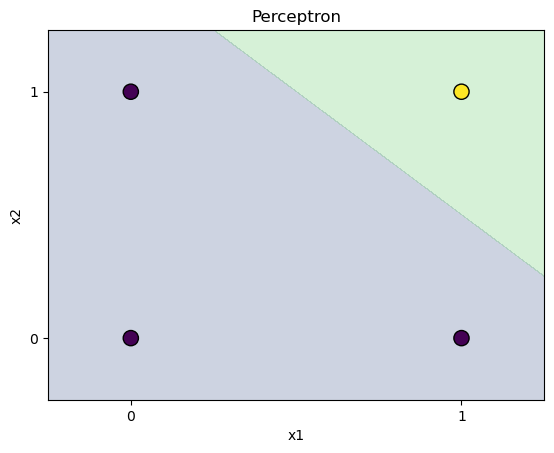

In [27]:
import matplotlib.pyplot as plt

def plot_perceptron(perceptron, X, y, title):
    x_min, x_max = -0.25, 1.25
    y_min, y_max = -0.25, 1.25
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = perceptron.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5])
    plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors="black")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.show()


y_and = np.array([0, 0, 0, 1])

plot_perceptron(logical_gate, X_logic, y_and, "Perceptron")

let's do it for an OR function
HINT: an OR function only it's 0 when both values are 0, otherwise it's 1

In [28]:
#TODO
#Let's make a perceptron for a OR function and graph it
#we first need to make the y vector for the or function
#Then create use the predict function with our perceptron and X_logic
#And use the plot perceptron function to graph it

In [29]:
#TODO
#LEt's make a perceptron for a XOR function and graph it
#XOR gates are only 1 when only one input is 1. If both are 0 or both are 1, the output is 0. 

turns out we can't! the XOR gate is not linearly separable. This was discovered in the monograph _Perceptrons_ made in 1969 by Marvin Minsky and Seymour Papert as one of the big weaknesses of perceptrons. how can we solve this?

## MultiLayer perceptrons

a multilayer perceptron, or MLP, is composed of one _input layer_, one or more layers of perceptrons called _hidden layers_, and one final layer of perceptrons called the _output layer_. When we have more than 2 layers (in old convention), we call it a _deep neural network_. For many years, researchers couldnt find an optimal way to train these models, it's so many parameters!

In [30]:
# A tiny MLP can solve XOR by combining simpler gates.
# Hidden neuron 1 behaves like OR.
# Hidden neuron 2 behaves like NAND.
# The output neuron behaves like AND.

hidden_weights = np.array([
    [1, 1],      # OR
    [-1, -1],    # NAND
])
hidden_bias = np.array([-0.5, 1.5])

hidden_output = step(X_logic @ hidden_weights.T + hidden_bias)

output_weights = np.array([1, 1])
output_bias = -1.5

xor_output = step(hidden_output @ output_weights + output_bias)

print("Inputs:")
print(X_logic)

print("Hidden layer output: [OR, NAND]")
print(hidden_output)

print("XOR output:")
print(xor_output)

Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Hidden layer output: [OR, NAND]
[[0 1]
 [1 1]
 [1 1]
 [1 0]]
XOR output:
[0 1 1 0]


it was until 1985 when David Rumelhart, Geoffrey Hinton and Ronald Williams published a paper called _Learning Internal Representations by Error Propagation_ that introduced the _backpropagation training algorithm_, which is used to this day (I use it in my thesis!).

In short terms, the algorithm:

* Do a forward pass (checks what's the output of the network with the current inputs and weights)
* Checks how far is the actual output of the _ideal output_ (that is, how far is the current answer to the real answer) using a _loss function_
* Check how each weight and bias should change to get closer to the actual answer (using gradient descent which is computation chain rule)
* rinse and repeat!

but there's a key issue with this. what happens if all our layers are still linears? We get a linear output! So they replaced the step function with a function called sigmoid (σ), defined by:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

this works because this function always has a derivative everywhere (that is, there's always room to change direction while doing the backpropagation).

we can always use a function called ReLU, which in practice works very better even if it doesnt have a derivative at 0

So, using non linear activation function, we can represent non linear functions!

There's a funny theorem related to this called the __Universal Approximation theorem__

> Given a standard neural network with just one hidden layer, we can approximate almost any continuous mathematical function to any desired degree of accuracy



## And how can we use this information?

Right now you are probably like this:

![img](https://images3.memedroid.com/images/UPLOADED151/6541471721c51.jpeg)

but dont worry! We'll get some exercises

## Final exercise: Neural Network Playground

Go to: https://playground.tensorflow.org/

Try to solve the XOR dataset.

Questions:

1. Can you solve XOR with no hidden layers?
2. What happens when you add one hidden layer?
3. How many neurons do you need?
4. What changes when you use ReLU vs sigmoid?
5. What happens if you increase the learning rate too much?
6. What happens if you add noise?